In [1]:
from vanna.openai.openai_chat import OpenAI_Chat
from vanna.chromadb.chromadb_vector import ChromaDB_VectorStore
import os
from dotenv import load_dotenv
load_dotenv()
api_key = os.getenv("VANNA_API_KEY")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
OPENAI_MODEL = "gpt-4o-mini"


In [12]:
from sqlalchemy import create_engine, text
import pandas as pd


In [13]:


# Load your SQLite database file
engine = create_engine("sqlite:///data/participants.db")

# Query to get schema objects and their creation SQL
query = text("SELECT type, sql FROM sqlite_master WHERE sql IS NOT NULL")

# Run the query and print results
with engine.connect() as conn:
    result = conn.execute(query)
    for row in result:
        print(f"{row.type.upper()}: {row.sql}\n")

TABLE: CREATE TABLE participants_structured (
	"SP ID" BIGINT, 
	"Gender" TEXT, 
	"Age" FLOAT, 
	"Work Experience/From Date" TEXT, 
	"Work Experience/To Date" TEXT, 
	"Languages" TEXT
)

TABLE: CREATE TABLE participants_unstructured (
	"SP ID" BIGINT, 
	"Work Experience/Company" TEXT, 
	"Work Experience/Designation" TEXT, 
	"Work Experience/Tasks" TEXT, 
	"Work Experience/Industry" TEXT, 
	"Education/Qualifications" TEXT, 
	"Education/Specialization" TEXT, 
	"Any Additional Skills" TEXT, 
	"Computer Skills" TEXT, 
	"Skills" TEXT, 
	"Languages" TEXT
)



In [2]:
class MyVanna(ChromaDB_VectorStore, OpenAI_Chat):
    def __init__(self, config=None):
        ChromaDB_VectorStore.__init__(self, config=config)
        OpenAI_Chat.__init__(self, config=config)

vn = MyVanna(config={"api_key": OPENAI_API_KEY, 'model': OPENAI_MODEL, "temperature": 0.0})

In [4]:
vn.connect_to_sqlite("data/participants.db")

In [5]:
df_ddl = vn.run_sql("SELECT type, sql FROM sqlite_master WHERE sql is not null")

In [6]:
for ddl in df_ddl['sql'].to_list():
    #print(ddl)
    vn.train(ddl=ddl)

Adding ddl: CREATE TABLE participants_structured (
	"SP ID" BIGINT, 
	"Gender" TEXT, 
	"Age" FLOAT, 
	"Work Experience/From Date" TEXT, 
	"Work Experience/To Date" TEXT, 
	"Languages" TEXT
)


/Users/adrianmarkelov/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:47<00:00, 1.75MiB/s]


Adding ddl: CREATE TABLE participants_unstructured (
	"SP ID" BIGINT, 
	"Work Experience/Company" TEXT, 
	"Work Experience/Designation" TEXT, 
	"Work Experience/Tasks" TEXT, 
	"Work Experience/Industry" TEXT, 
	"Education/Qualifications" TEXT, 
	"Education/Specialization" TEXT, 
	"Any Additional Skills" TEXT, 
	"Computer Skills" TEXT, 
	"Skills" TEXT, 
	"Languages" TEXT
)


In [19]:
vn.train(question="Show all participants over 40", sql="SELECT * FROM participants_structured WHERE Age > 40")


'330dfbd7-2926-5da6-8643-10768bec2864-sql'

In [7]:
training_data = vn.get_training_data()
print(training_data)

                                         id question  \
0  19948383-a6a5-536e-b80b-5e4fbe795a7c-ddl     None   
1  3e17f3fb-bb4c-53bb-88e0-13e0977a8647-ddl     None   

                                             content training_data_type  
0  CREATE TABLE participants_structured (\n\t"SP ...                ddl  
1  CREATE TABLE participants_unstructured (\n\t"S...                ddl  


In [18]:
print(df_ddl['sql'][0])

CREATE TABLE participants_structured (
	"SP ID" BIGINT, 
	"Gender" TEXT, 
	"Age" FLOAT, 
	"Work Experience/From Date" TEXT, 
	"Work Experience/To Date" TEXT, 
	"Languages" TEXT
)


Number of requested results 10 is greater than number of elements in index 3, updating n_results = 3
Number of requested results 10 is greater than number of elements in index 2, updating n_results = 2


SQL Prompt: [{'role': 'system', 'content': 'You are a SQLite expert. Please help to generate a SQL query to answer the question. Your response should ONLY be based on the given context and follow the response guidelines and format instructions. \n===Tables \nCREATE TABLE participants_structured (\n\t"SP ID" BIGINT, \n\t"Gender" TEXT, \n\t"Age" FLOAT, \n\t"Work Experience/From Date" TEXT, \n\t"Work Experience/To Date" TEXT, \n\t"Languages" TEXT\n)\n\nCREATE TABLE participants_unstructured (\n\t"SP ID" BIGINT, \n\t"Work Experience/Company" TEXT, \n\t"Work Experience/Designation" TEXT, \n\t"Work Experience/Tasks" TEXT, \n\t"Work Experience/Industry" TEXT, \n\t"Education/Qualifications" TEXT, \n\t"Education/Specialization" TEXT, \n\t"Any Additional Skills" TEXT, \n\t"Computer Skills" TEXT, \n\t"Skills" TEXT, \n\t"Languages" TEXT\n)\n\n===Response Guidelines \n1. If the provided context is sufficient, please generate a valid SQL query without any explanations for the question. \n2. If the p

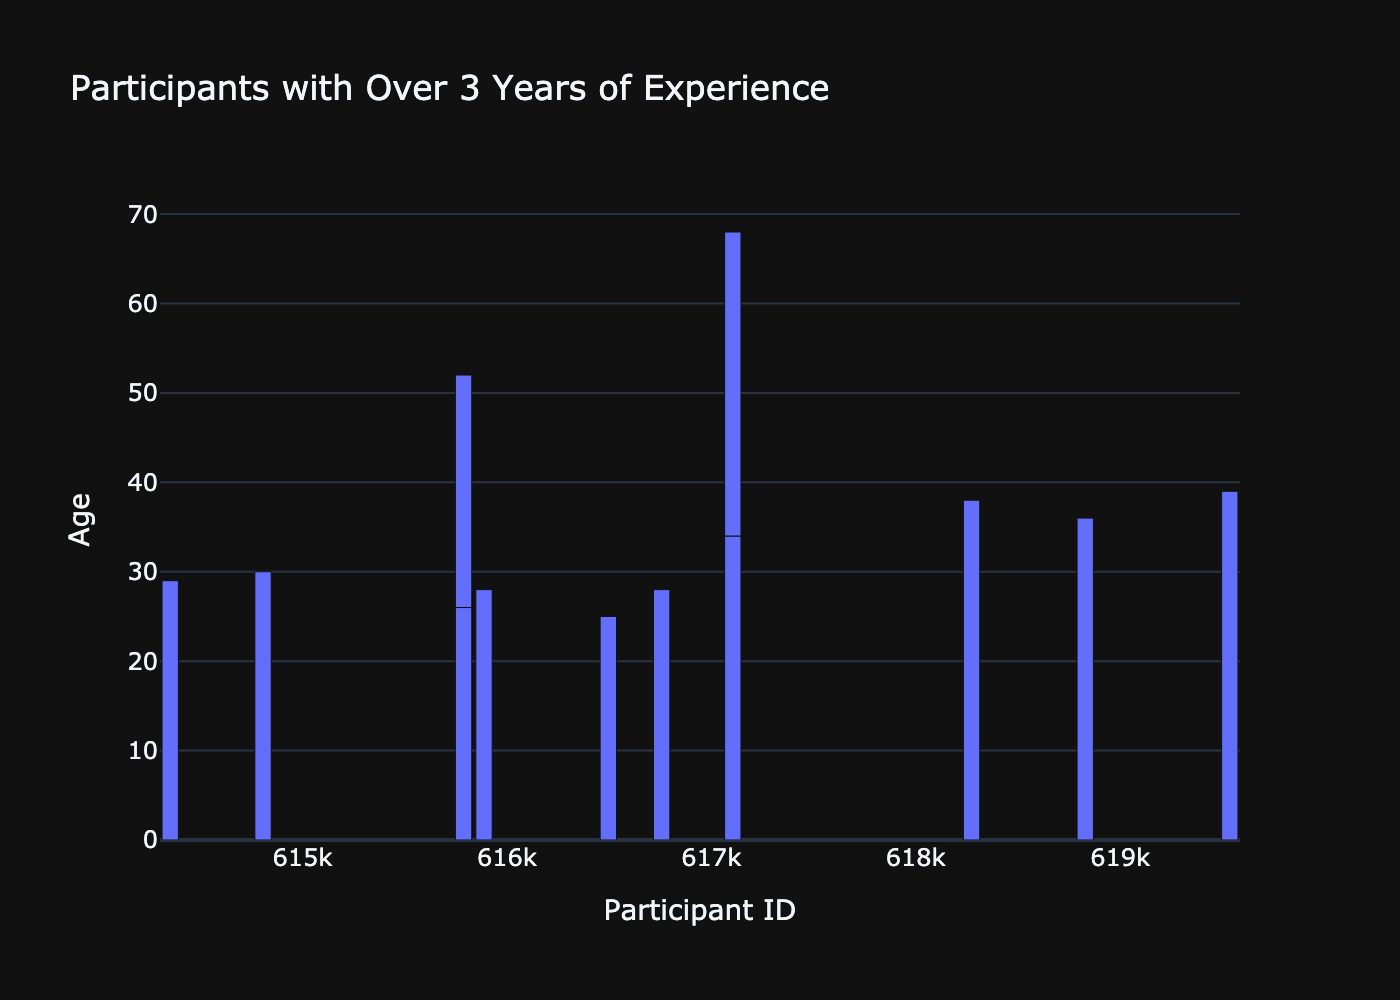

('SELECT * FROM participants_structured \nWHERE (julianday("Work Experience/To Date") - julianday("Work Experience/From Date")) / 365 > 3;',
      SP ID  Gender   Age Work Experience/From Date Work Experience/To Date  \
 0   619536    Male  39.0                2009-01-01              2012-12-06   
 1   618829    Male  36.0                2014-12-20              2024-07-01   
 2   618273    Male  38.0                2017-05-15              2023-12-30   
 3   617105  Female  34.0                2013-07-01              2019-07-30   
 4   617105  Female  34.0                2019-08-01              2024-07-19   
 5   616757  Female  28.0                2018-03-01              2022-08-07   
 6   616496    Male  25.0                2021-03-01              2024-07-01   
 7   615888  Female  28.0                2016-11-14              2024-10-16   
 8   615788    Male  26.0                2020-01-07              2024-09-01   
 9   615788    Male  26.0                2019-03-01              2024

In [21]:
vn.ask(question="Show all participants with over 3 years of experience")

In [13]:

from langchain_core.prompts.chat import ChatPromptTemplate




In [29]:
text_to_sql_tmpl = """\
Given an input question, first create a syntactically correct {dialect} query to run, then look at the results of the query and return the answer.
You can order the results by a relevant column to return the most interesting examples in the database.

Pay attention to use only the column names that you can see in the schema description. Be careful to not query for columns that do not exist.
Pay attention to which column is in which table. Also, qualify column names with the table name when needed.

IMPORTANT NOTE: You can use specialized pgvector syntax (`<=>`) to do nearest neighbors/semantic search to a given vector from an embeddings column in the table.
The embeddings value for a given row typically represents the semantic meaning of that row.
**Do NOT fill in the vector values directly**, but rather specify placeholders in the format `[query_vector_X]` where X is a number.
In addition, provide a JSON object mapping each placeholder (e.g., "query_vector_1") to the search string that should be embedded.
For instance, if the user question is "Show me participants with experience in data science and machine learning" and your query uses two vector search placeholders, then your output should include:
"query": "SELECT ... WHERE field1_embedding <=> '[query_vector_1]' ... AND field2_embedding <=> '[query_vector_2]' ...",
"vector_searches":
    "query_vector_1": "data science",
    "query_vector_2": "machine learning"


Only use tables listed below.
{schema}

Question: {input}
SQLQuery:\
"""

vector_sql_prompt_template = ChatPromptTemplate.from_template(text_to_sql_tmpl)

In [30]:
vector_sql_prompt_template

ChatPromptTemplate(input_variables=['dialect', 'input', 'schema'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['dialect', 'input', 'schema'], input_types={}, partial_variables={}, template='Given an input question, first create a syntactically correct {dialect} query to run, then look at the results of the query and return the answer.\nYou can order the results by a relevant column to return the most interesting examples in the database.\n\nPay attention to use only the column names that you can see in the schema description. Be careful to not query for columns that do not exist.\nPay attention to which column is in which table. Also, qualify column names with the table name when needed.\n\nIMPORTANT NOTE: You can use specialized pgvector syntax (`<=>`) to do nearest neighbors/semantic search to a given vector from an embeddings column in the table.\nThe embeddings value for a given row typically represents the seman

In [16]:
prompt = vector_sql_prompt_template.invoke(
            {
                "dialect": "postgres",
                "schema": "table info",
                "input": "Give me participants",
            }
        )

print(prompt)

messages=[HumanMessage(content='Given correct postgres query\ntable info\nQuestion: Give me participants\nSQLQuery:', additional_kwargs={}, response_metadata={})]
